## Forecasting Short-Term Shell Congestion Using Regression

This notebook estimates **short-term congestion trends** in each orbital shell (KMeans cluster).  
It uses only the information inside the **current dataset snapshot**.

### How it works
- Satellites are assigned to shells using **KMeans (CLUSTER)**.
- Each satellite has an **EPOCH date**, which tells when its orbital data was last updated.
- We group satellites by **CLUSTER + EPOCH (day)** to get:
  
  **“How many satellites were updated in this shell on this date?”**

- Using these counts, we fit a simple regression line to understand the **trend**:
  - Rising → congestion increasing  
  - Stable → congestion steady  
  - Falling → congestion reducing  

### Important Note
The regression **does not predict exact future satellite counts**.  
It only shows the **trend direction** inside the current dataset, which helps us judge if an orbital shell is:

- **Safe**
- **Moderate Risk**
- **High Risk**

for a new satellite launch based on **today’s congestion and trend**.

This makes the forecasting realistic, lightweight, and reliable without needing long-term historical data.


In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline

#### Import necessary datasets

In [200]:
df = pd.read_csv('../data/06_streamlit_ready/anomaly_clustered.csv')

In [201]:
df.head(2)

,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,...,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE,CLUSTER,ANOMALY_LABEL,ANOMALY_SCORE
0,CALSPHERE 1,2025-12-04 15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,900,4466,...,7354.923145,983.923145,956.945702,996.900587,7.361725,61.925,C,2,-1,-0.115605
1,CALSPHERE 2,2025-12-04 14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,902,82995,...,7439.741868,1068.741868,1046.564050,1076.919685,7.319640,61.925,E,2,-1,-0.084349


---
### Extract necessary features for forecasting

In [202]:
df = df[['EPOCH', 'NORAD_CAT_ID', 'CLUSTER']] 

In [203]:
df.shape

(12747, 3)

In [204]:
df['CLUSTER'].value_counts().sort_values()

CLUSTER
3     184
2    1458
4    2106
0    4389
1    4610
Name: count, dtype: int64

---
### Prepare time column
- Convert epoch to DateTime object
- Extract the day (not time)

In [205]:
df['EPOCH'] = pd.to_datetime(df['EPOCH'])

In [206]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12747 entries, 0 to 12746
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   EPOCH         12747 non-null  datetime64[ns]
 1   NORAD_CAT_ID  12747 non-null  int64         
 2   CLUSTER       12747 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 298.9 KB


In [207]:
df['EPOCH'] = df['EPOCH'].dt.floor('D')

In [208]:
# Create simple time series dataset
shell_time_series = df.groupby(['EPOCH', 'CLUSTER']).size().reset_index(name='SATELLITE_COUNT')

In [209]:
shell_time_series

,EPOCH,CLUSTER,SATELLITE_COUNT
0,2025-11-08,0,1
1,2025-11-20,2,1
2,2025-11-21,4,1
3,2025-11-23,0,1
4,2025-11-23,4,1
5,2025-11-24,2,1
6,2025-11-26,4,1
7,2025-11-28,4,1
8,2025-11-29,4,2
9,2025-11-30,1,1


---
### Save in a CSV file

In [210]:
shell_time_series.to_csv('../data/06_streamlit_ready/shell_time_series.csv')

### Apply regression on the created time series dataset :

### Meaning of Activity Fraction

`ACTIVITY_FRACTION` represents how active a shell is based on how many of its satellites were recently updated.

It is calculated as:

**activity_fraction = (satellites updated on this date) / (total updates in this shell)**

Values are between 0 and 1:

- **Closer to 1** → high recent activity (busy or unstable shell)  
- **Closer to 0** → low recent activity (stable shell)

Regression is applied to this fraction to understand whether the shell’s activity is rising, stable, or falling.


In [211]:
from sklearn.linear_model import LinearRegression

In [212]:
cluster_models = [] # Store cluster specific model information
activity_df = pd.DataFrame() # Store cluster data with fraction for each day

for cluster in range(shell_time_series['CLUSTER'].nunique()):
    # Filter rows for the current cluster
    cluster_rows = shell_time_series[shell_time_series['CLUSTER'] == cluster].copy()
    

    # Convert EPOCH into numeric days starting from the earliest date
    cluster_rows['EPOCH_NUM'] = (
        (cluster_rows["EPOCH"] - cluster_rows["EPOCH"].min()).dt.total_seconds() / (24 * 3600)
    )

    # Compute activity fraction for regression target
    total_updates = cluster_rows['SATELLITE_COUNT'].sum()
    cluster_rows['ACTIVITY_FRACTION'] = cluster_rows['SATELLITE_COUNT'] / total_updates

    # Add the cluster rows to the activity_df
    activity_df = pd.concat([activity_df, cluster_rows])

    
    # Skip regressing clusters that have fewer than 3 data points
    if len(cluster_rows) < 3:
        current_fraction = round(cluster_rows['ACTIVITY_FRACTION'].iloc[-1], 5)

        cluster_models.append({
            'Cluster': cluster,
            'Model': None,
            'Slope': 0,
            'Intercept': None,
            'Current activity fraction': current_fraction
        })
        print(f"[WARNING] Cannot regress cluster {cluster} (only) {len(cluster_rows)} point(s) ")
        continue
    
    # Set up regression inputs
    X = cluster_rows[['EPOCH_NUM']]
    y = cluster_rows[['ACTIVITY_FRACTION']]

    # Fit the regression model
    model = LinearRegression()
    model.fit(X, y)

    # Extract slope, intercept and latest fraction
    slope = round(model.coef_[0][0], 5)
    intercept = round(model.intercept_[0], 5)
    current_fraction = round(y.iloc[-1].values[0], 5)
    


    # Store model details
    cluster_models.append({
        'Cluster': cluster,
        'Model': model,
        'Slope': slope,
        'Intercept': intercept,
        'Current activity fraction': current_fraction
    })

# Reset activity_df index
activity_df = activity_df.reset_index(drop=True)

[WARNING] Cannot regress cluster 3 (only) 1 point(s) 


In [213]:
activity_df

,EPOCH,CLUSTER,SATELLITE_COUNT,EPOCH_NUM,ACTIVITY_FRACTION
0,2025-11-08,0,1,0.0,0.000228
1,2025-11-23,0,1,15.0,0.000228
2,2025-12-02,0,4,24.0,0.000911
3,2025-12-03,0,85,25.0,0.019367
4,2025-12-04,0,4298,26.0,0.979266
5,2025-11-30,1,1,0.0,0.000217
6,2025-12-02,1,4,2.0,0.000868
7,2025-12-03,1,220,3.0,0.047722
8,2025-12-04,1,4385,4.0,0.951193
9,2025-11-20,2,1,0.0,0.000686


In [214]:
cluster_models

[{'Cluster': 0,
  'Model': LinearRegression(),
  'Slope': np.float64(0.01654),
  'Intercept': np.float64(-0.09765),
  'Current activity fraction': np.float64(0.97927)},
 {'Cluster': 1,
  'Model': LinearRegression(),
  'Slope': np.float64(0.19425),
  'Intercept': np.float64(-0.18706),
  'Current activity fraction': np.float64(0.95119)},
 {'Cluster': 2,
  'Model': LinearRegression(),
  'Slope': np.float64(0.03463),
  'Intercept': np.float64(-0.09778),
  'Current activity fraction': np.float64(0.9904)},
 {'Cluster': 3,
  'Model': None,
  'Slope': 0,
  'Intercept': None,
  'Current activity fraction': np.float64(1.0)},
 {'Cluster': 4,
  'Model': LinearRegression(),
  'Slope': np.float64(0.03197),
  'Intercept': np.float64(-0.14619),
  'Current activity fraction': np.float64(0.97768)}]

---
### Visualizing the model O/P

#### Activity Fraction vs Time (Per Cluster) + Regression trend line

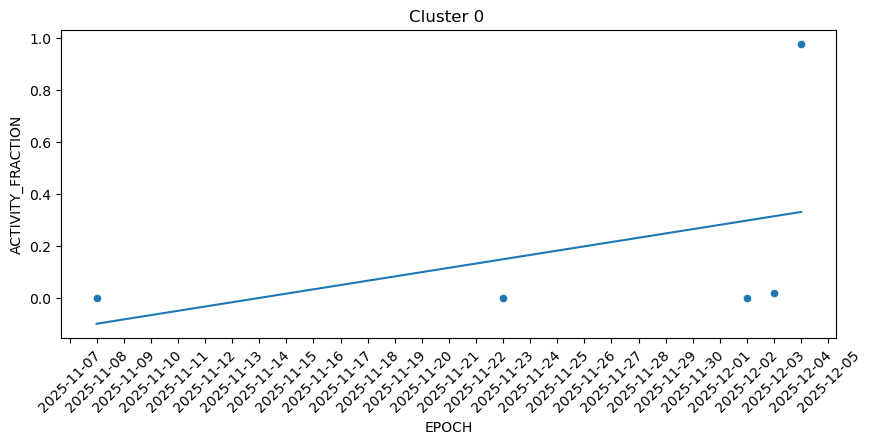

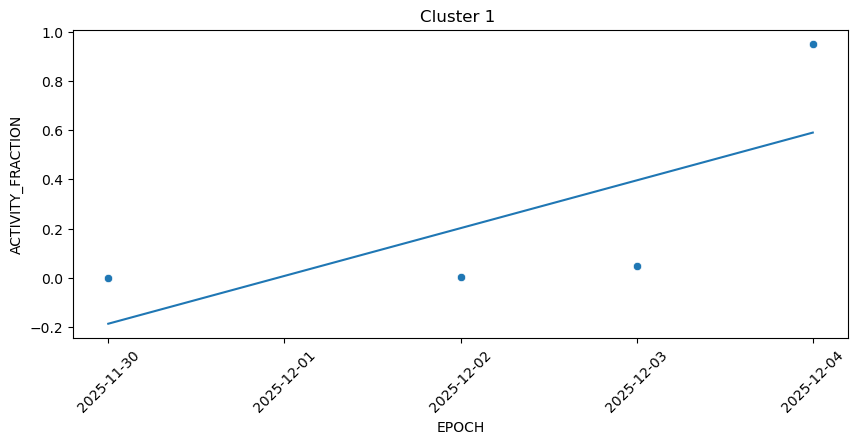

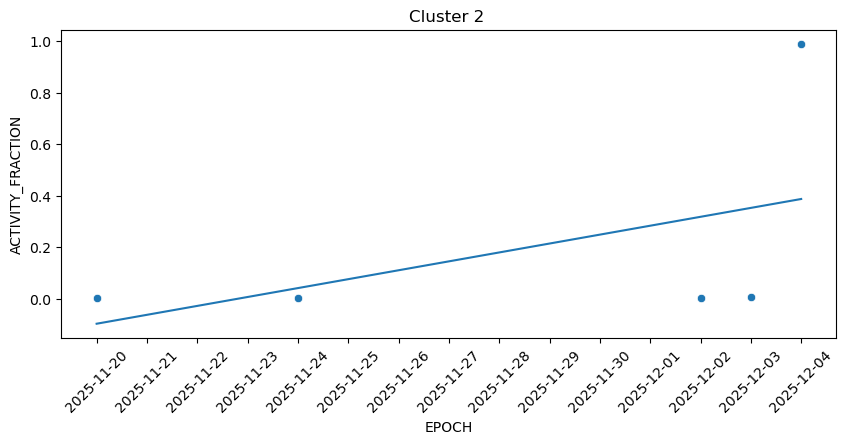

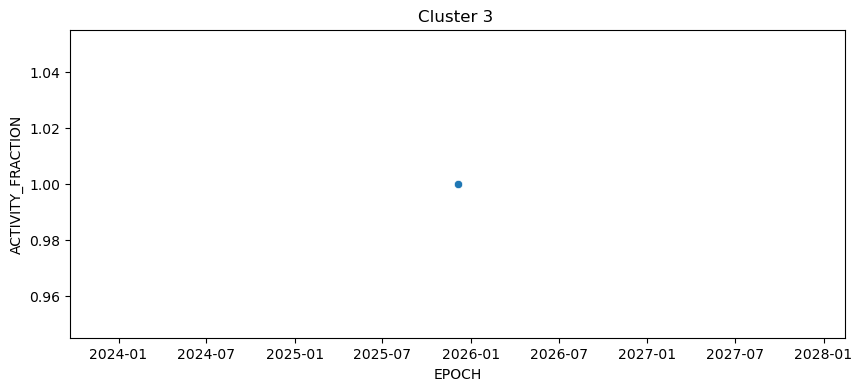

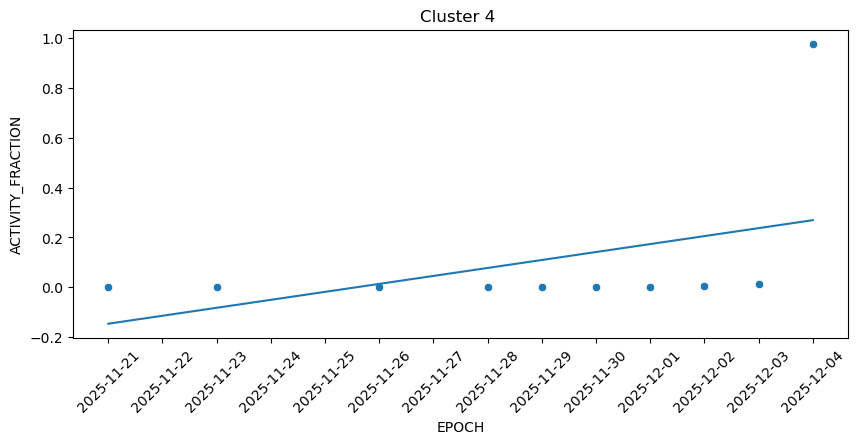

In [215]:
import matplotlib.dates as mdates

for cluster in range(activity_df['CLUSTER'].nunique()):

    plt.figure(figsize=(10, 4))
    plt.title(F'Cluster {cluster} ')
    cluster_rows = activity_df[activity_df['CLUSTER'] == cluster].copy()
    
    # Plot raw data points
    sns.scatterplot(data=cluster_rows, x = 'EPOCH', y = 'ACTIVITY_FRACTION')

    # Obtain perticular model for this cluster and plot the regression line
    model = cluster_models[cluster]['Model']
    if model is None:
        continue

    y_pred = model.predict(cluster_rows[['EPOCH_NUM']])
    plt.plot(cluster_rows['EPOCH'], y_pred)

    # Resolve the date tick label issue
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())

    
    plt.xticks(rotation=45)

#### Cluster Comparison

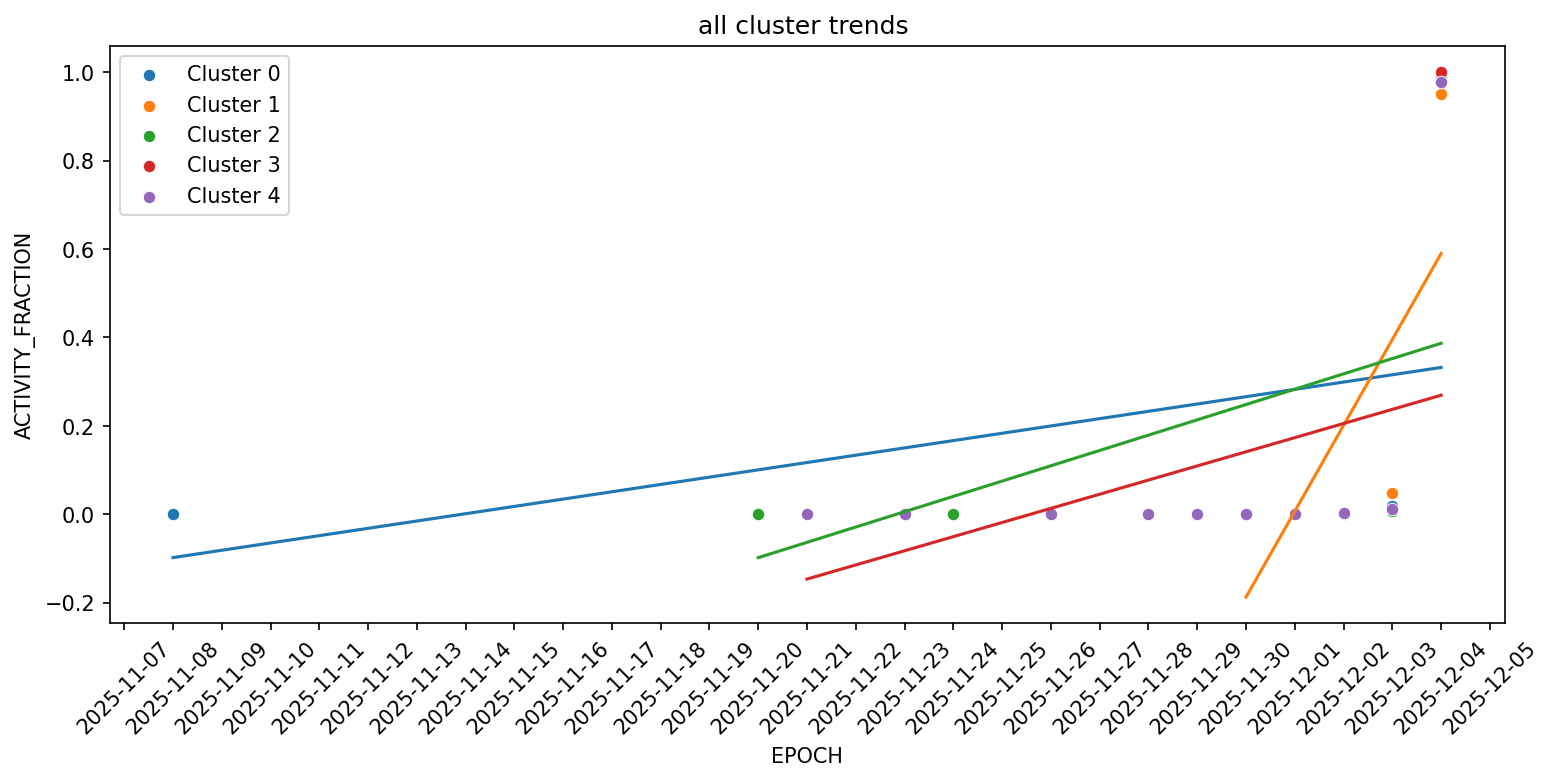

In [216]:

plt.figure(figsize=(12, 5), dpi=150)
for cluster in range(activity_df['CLUSTER'].nunique()):

    plt.title(F'all cluster trends ')
    cluster_rows = activity_df[activity_df['CLUSTER'] == cluster].copy()
    
    # Plot raw data points
    sns.scatterplot(data=cluster_rows, x = 'EPOCH', y = 'ACTIVITY_FRACTION', label=f'Cluster {cluster}')

    # Obtain perticular model for this cluster and plot the regression line
    model = cluster_models[cluster]['Model']
    if model is None:
        continue

    y_pred = model.predict(cluster_rows[['EPOCH_NUM']])
    plt.plot(cluster_rows['EPOCH'], y_pred)

    # Resolve the date tick label issue
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    
    plt.legend()
    plt.xticks(rotation=45)

#### Final Trend Summary
- Final trend summary will not just take raw time series data as input, but also take in mind potential anomalies in the clusters.

In [217]:
trend_summary = pd.DataFrame(columns=['CLUSTER_ID', 'SLOPE', 'CURRENT_ACTIVITY_FRACTION', 'TREND_TYPE', 'LAUNCH_RISK_LEVEL'])

"""
Define trend type based on 'relative' slope in each cluster : 
    
    normalized = slope / max_slope (bewteen  0 to 1)
    
    > 0.70     → Strong Rising
    0.30–0.70  → Moderate Rising
    0.10–0.30  → Mild Rising
    -0.10–0.10 → Flat
    < -0.10    → Calming
 """

"""
Launch Risk Rules (Enhanced: Trend + Activity + Anomaly Stability)

1) Base Risk (from trend + activity):
    High      → slope ≥ 0.30  AND  activity > 0.30
    Moderate  → slope 0.00–0.29  OR  activity 0.10–0.35
    Low       → activity < 0.10  OR  trend flat/calming

2) Anomaly Stability Modifier:
    anomaly_rate > 0.15  → increase risk by one level
    anomaly_rate < 0.05  → decrease risk if borderline
    otherwise            → keep base risk same

Final Risk = Base Risk adjusted by anomaly stability.
"""


min_slope = min(d['Slope'] for d in cluster_models)
max_slope = max(d['Slope'] for d in cluster_models)
# Read the df containing anomaly label
df = pd.read_csv('../data/06_streamlit_ready/anomaly_clustered.csv')

 
# Use the clustered_model to add the cluster related information obtained through regression
for item in cluster_models:
    cluster = item['Cluster']
    slope = item['Slope']
    current_fraction = item['Current activity fraction']

    if item['Model'] is None:
        trend_type = 'No Trend'
        base_risk_level = 'N/A'

        trend_summary.loc[len(trend_summary)] = [cluster, slope, current_fraction, trend_type, base_risk_level]
        continue
    # 1. Relative slope strength/trend
    # Scale the relative strength betwwen 0 to 1
    normalized = (slope - min_slope) / (max_slope - min_slope) 

    # Trend classification
    if normalized > 0.70:
        trend_type = 'Strong Rising'
    elif normalized >= 0.30:
        trend_type = 'Moderate Rising'
    elif normalized >= 0.10:
        trend_type = 'Mild Rising'
    elif normalized >= -0.10:
        trend_type = 'Flat'
    else:
        trend_type = 'Calming'


    # 2. Launch risk score classification -> Base risk
    if (normalized >0.3) and (current_fraction >0.3): # Strong & Moderate rising
        base_risk_level = 'High'
    elif (0.29>=normalized>=0.0) and (0.35>=current_fraction>=0.0): # Mild rising / any rising trend
        base_risk_level = 'Moderate'
    else: # Flat / Stable / Calming
        base_risk_level = 'Low'
        
    # 3. Compute anomaly rate and find final risk score
    cluster_data = df[df['CLUSTER'] == cluster]
    total_sats = len(cluster_data)
    total_anomalies = len(cluster_data[cluster_data['ANOMALY_LABEL'] == -1])

    anomaly_rate =  total_anomalies / total_sats # Compute anomaly rate

    # Adjust risk based on the anomaly rate
    if anomaly_rate > 0.15:
        # Increase risk by one level
        if base_risk_level == 'Low':
            final_risk_level = 'Moderate'
        elif base_risk_level == 'Moderate':
            final_risk_level = 'High'
        else:
            final_risk_level = base_risk_level
    
    elif anomaly_rate < 0.05:
        # Decrease risk by one level
        if base_risk_level == 'high':
            final_risk_level = 'Moderate'
        elif base_risk_level == 'Moderate':
            final_risk_level = 'Low'
        else:
            final_risk_level = base_risk_level
    else:
        final_risk_level = base_risk_level

    # 4. Append row data
    trend_summary.loc[len(trend_summary)] = [cluster, slope, current_fraction, trend_type, final_risk_level]
    
    

In [219]:
trend_summary

,CLUSTER_ID,SLOPE,CURRENT_ACTIVITY_FRACTION,TREND_TYPE,LAUNCH_RISK_LEVEL
0,0,0.01654,0.97927,Flat,Low
1,1,0.19425,0.95119,Strong Rising,High
2,2,0.03463,0.99040,Mild Rising,Low
3,3,0.00000,1.00000,No Trend,N/A
4,4,0.03197,0.97768,Mild Rising,Low


In [220]:
cluster_models

[{'Cluster': 0,
  'Model': LinearRegression(),
  'Slope': np.float64(0.01654),
  'Intercept': np.float64(-0.09765),
  'Current activity fraction': np.float64(0.97927)},
 {'Cluster': 1,
  'Model': LinearRegression(),
  'Slope': np.float64(0.19425),
  'Intercept': np.float64(-0.18706),
  'Current activity fraction': np.float64(0.95119)},
 {'Cluster': 2,
  'Model': LinearRegression(),
  'Slope': np.float64(0.03463),
  'Intercept': np.float64(-0.09778),
  'Current activity fraction': np.float64(0.9904)},
 {'Cluster': 3,
  'Model': None,
  'Slope': 0,
  'Intercept': None,
  'Current activity fraction': np.float64(1.0)},
 {'Cluster': 4,
  'Model': LinearRegression(),
  'Slope': np.float64(0.03197),
  'Intercept': np.float64(-0.14619),
  'Current activity fraction': np.float64(0.97768)}]